In [1]:
import sys

sys.path.append("..")
from pathlib import Path

import numpy as np
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader

from SpecEmbedding.const import gnps
from SpecEmbedding.data.datasets import TrainDataset
from SpecEmbedding.data.tokenizer import Tokenizer
from SpecEmbedding.loss import SupConLoss, SupConLossWithTanimotoScore, TanimotoScoreLoss
from SpecEmbedding.trainer.fn import step_evaluate, step_train
from SpecEmbedding.trainer.trainer import Trainer, set_seed
from SpecEmbedding.type import (
    AugmentationConfig,
    DataLoaderConfig,
    DescriptionConfig,
    OptimizerConfig,
    SchedulerConfig,
    StepFuncConfig,
    StorageConfig,
    SupConLossConfig,
    SupConLossWithTanimotoScoreConfig,
    TanimotoLossConfig,
    TokenizerConfig,
    TrainerConfig,
)
from SpecEmbedding.utils.clean import get_classified_tokenset
from SpecEmbedding.utils.model import SiameseModel

In [ ]:
# load data
labels_dir = Path("/data1/xp/data/labels")
labels_dir.mkdir(parents=True, exist_ok=True)

train_spectra = np.load(gnps.ORBITRAP_TRAIN_REF, allow_pickle=True)
unique_smiles = np.load(
    gnps.DIR / gnps.UNIQUE_SMILES,
    allow_pickle=True
)
print("load data success")

# tokenization
tokenizer_config = TokenizerConfig(
    max_len=100,
    show_progress_bar=True
)
tokenizer = Tokenizer(**tokenizer_config)
sequences = tokenizer.tokenize_sequence(train_spectra)
data, labels = get_classified_tokenset(unique_smiles, sequences)
np.save(labels_dir / "data.npy", data)
np.save(labels_dir / "labels.npy", labels)
print("finish the tokenize process")

In [5]:
data = np.load(labels_dir / "data.npy", allow_pickle=True).item()
labels = np.load(labels_dir / "labels.npy", allow_pickle=True)

In [6]:
seed = set_seed(42)

is_augment = True

augment_config = AugmentationConfig(
    prob=0.5,
    removal_max=0.2,
    removal_intensity=0.3,
    rate_intensity=0.15,
)

# dataset and dataloader
dataloader_config = DataLoaderConfig(
    batch_size=512,
    val_ratio=0.2
)

length = len(labels)
val_indices = np.random.choice(
    np.arange(length), 
    int(dataloader_config["val_ratio"] * length), 
    replace=False
)
val_keys = labels[val_indices]
train_keys = np.delete(labels, val_indices)

train_dataset = TrainDataset(
    data=data,
    keys=train_keys,
    n_views=2,
    is_augment=is_augment,
    augment_config=augment_config
)

val_dataset = TrainDataset(
    data=data,
    keys=val_keys,
    n_views=2
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=dataloader_config["batch_size"],
    shuffle=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=dataloader_config["batch_size"],
    shuffle=True
)

In [7]:
loss_type = "SupConWithTanimotoLoss"
model_backbone = "transformer"

In [ ]:
# model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = SiameseModel(
    512,
    16,
    4,
    512,
    512,
    feedward_activation="selu",
)
model = model.to(device)

# trainer
trainer_config = TrainerConfig(
    n_epoch=50,
    device=device,
    early_stop=20,
    show_progress_bar=True
)
# scheduler
n_step = trainer_config["n_epoch"] * len(train_dataloader)
scheduler_config = SchedulerConfig(
    warmup_steps=int(n_step * 0.1),
    total_steps=n_step
)

# loss
reduction = "mean"
tanimoto_score_path = "/data1/xp/data/MSBert/GNPS/tanimoto_score.npy"
if loss_type == "SupConLoss":
    loss_config = SupConLossConfig(
        device=device,
        temperature=0.01,
        base_temperature=0.5,
        contrast_mode='all',
        reduction=reduction
    )
    criterion = SupConLoss(**loss_config)
elif loss_type == "TanimotoLoss":
    loss_config = TanimotoLossConfig(
        score_path=tanimoto_score_path,
        device=device,
        reduction=reduction
    )
    criterion = TanimotoScoreLoss(**loss_config)
elif loss_type == "SupConWithTanimotoLoss":
    loss_config = SupConLossWithTanimotoScoreConfig(
        alpha=30,
        score_path=tanimoto_score_path,
        device=device,
        temperature=0.05,
        contrast_mode="all",
        base_temperature=0.05,
        reduction=reduction
    )
    criterion = SupConLossWithTanimotoScore(**loss_config)

# optimizer
optimizer_config = OptimizerConfig(
    lr=7.5e-5,
    weight_decay=0.1
)
optimizer = AdamW(model.parameters(), **optimizer_config)

# desc
desc_config = DescriptionConfig(
    train="train, epoch={}, loss={:.4f}",
    val="validation, epoch={}, loss={:.4f}, save the model",
    end="model train end, best model loss={:.4f}"
)
# step func
stepfunc_config = StepFuncConfig(
    train=step_train,
    val=step_evaluate
)

suffix = ""
if is_augment:
    suffix = "-Augmentation"

# storage
model_dir = Path(f"/data1/xp/data/model/{model_backbone}-{loss_type}{suffix}")

model_dir.mkdir(parents=True, exist_ok=True)
storage_config = StorageConfig(
    model=model_dir / "model.ckpt",
    lr=model_dir / "lr.npy",
    step_loss=model_dir / "step_loss.npy",
    loss=model_dir / "epoch_loss.npy",
    custom=model_dir / "custom_metric.npy"
)

In [7]:
# model train
torch.cuda.empty_cache()
trainer = Trainer(
    model,
    reduction,
    train_dataloader,
    val_dataloader,
    optimizer,
    criterion,
    device,
    stepfunc_config,
    desc_config,
    storage_config,
    trainer_config,
    scheduler_config
)

trainer.train()

Train: Epoch [1/50]:   0%|          | 0/128 [00:00<?, ?it/s]

Train: Epoch [1/50]: 100%|██████████| 128/128 [01:15<00:00,  1.69it/s, loss=2.0161]


train, epoch=1, loss=3.9385


Validation: Epoch [1/50]: 100%|██████████| 32/32 [00:06<00:00,  4.66it/s, loss=2.9506]


validation, epoch=1, loss=3.6635, save the model


...

train, epoch=49, loss=0.2858


Train: Epoch [50/50]: 100%|██████████| 128/128 [01:16<00:00,  1.67it/s, loss=0.1995]


train, epoch=50, loss=0.2845


Validation: Epoch [50/50]: 100%|██████████| 32/32 [00:06<00:00,  4.67it/s, loss=1.0911]


best model saved in epoch 38
model train end, best model loss=1.1138
store train metrics


<Axes: >

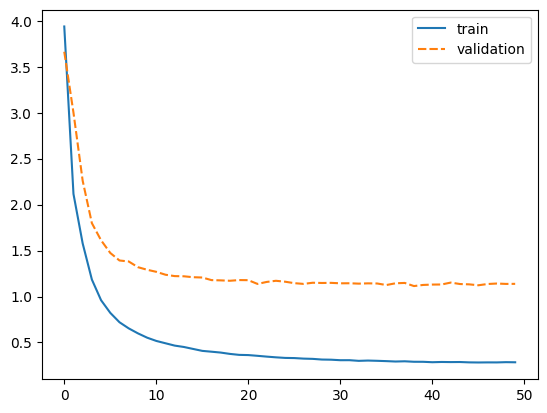

In [10]:
import numpy as np
import seaborn as sns

loss = np.load(model_dir / "epoch_loss.npy", allow_pickle=True).item()
sns.lineplot(loss)

<Axes: >

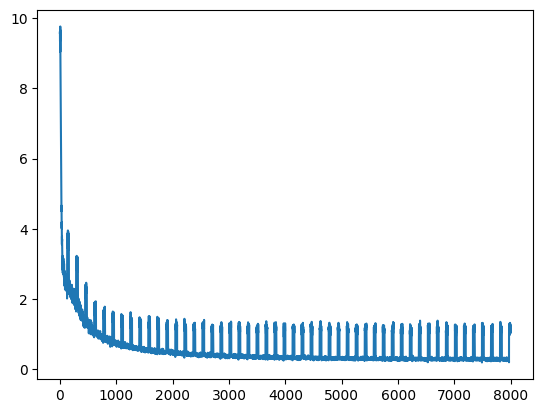

In [11]:
import numpy as np
import seaborn as sns

loss = np.load(model_dir / "step_loss.npy", allow_pickle=True)
sns.lineplot(loss)